C:\Users\Tanvir Hassan\AppData\Local\Temp\ipykernel_11804\852978272.py:70: RuntimeWarning: invalid value encountered in divide
  U, V = U / norm, V / norm


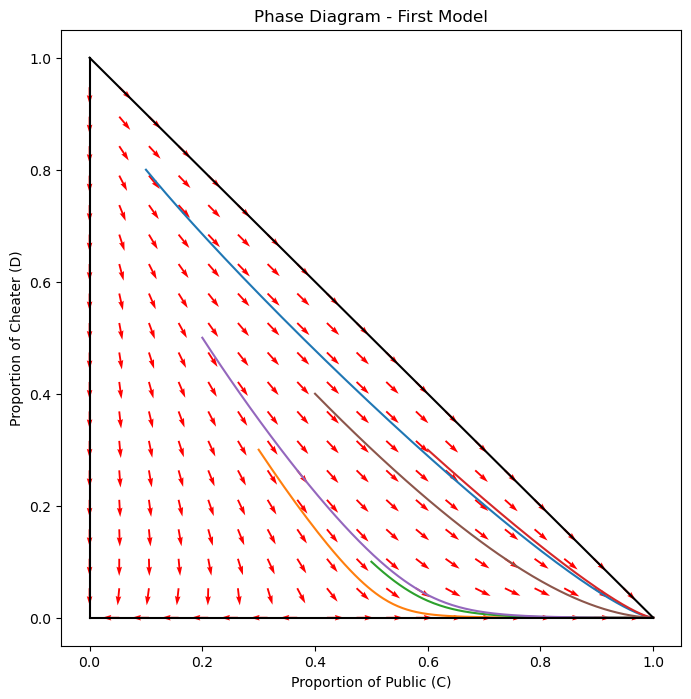

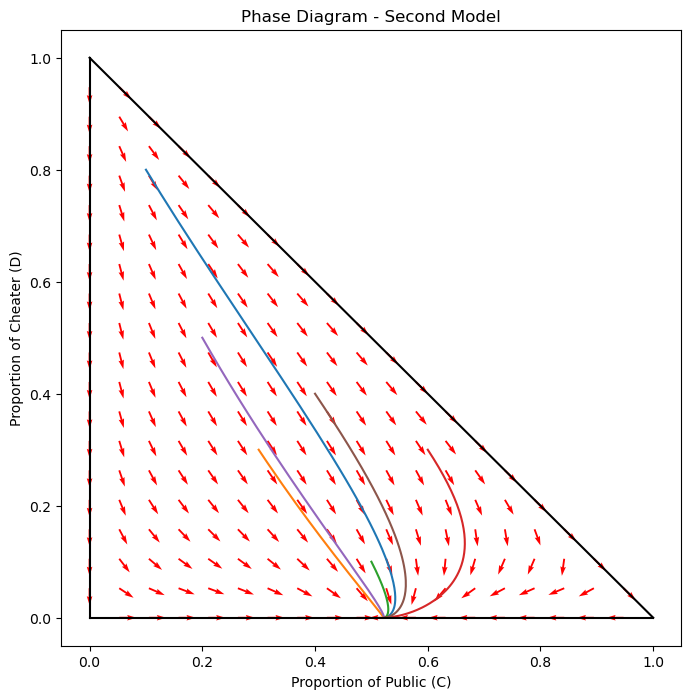

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the fitness functions for the first and second models
def fitness_first_model(x, params):
    x_C, x_D, x_P = x
    r_c, alpha, beta, nu, r_p, eta = params
    
    f_C = r_c * x_C + (r_c - alpha) * x_D + (r_c - beta) * x_P
    f_D = alpha * x_C - nu * x_D
    f_P = (r_p - eta) * x_C + r_p * x_P
    
    return f_C, f_D, f_P

def fitness_second_model(x, params):
    x_C, x_D, x_P = x
    r_c, alpha, beta, nu, r_p, eta, lambda_, gamma = params
    
    f_C = r_c - lambda_ * x_C + (r_c - alpha) * x_D + (r_c - beta) * x_P
    f_D = alpha * x_C - nu * x_D
    f_P = (r_p - eta) * x_C + r_p - gamma * x_P
    
    return f_C, f_D, f_P

# Define the replicator dynamics equations for both models
def replicator_dynamics(x, t, params, model='first'):
    x_C, x_D, x_P = x
    if model == 'first':
        f_C, f_D, f_P = fitness_first_model(x, params)
    elif model == 'second':
        f_C, f_D, f_P = fitness_second_model(x, params)
    
    avg_fitness = x_C * f_C + x_D * f_D + x_P * f_P
    dx_C = x_C * (f_C - avg_fitness)
    dx_D = x_D * (f_D - avg_fitness)
    dx_P = x_P * (f_P - avg_fitness)
    
    return [dx_C, dx_D, dx_P]

# Initial parameters for both models
params_first_model = [1.0, 0.5, 0.2, 0.1, 1.0, 0.3]  # r_c, alpha, beta, nu, r_p, eta
params_second_model = [1.0, 0.5, 0.2, 0.1, 1.0, 0.3, 0.4, 0.4]  # r_c, alpha, beta, nu, r_p, eta, lambda, gamma

# Time range for simulation
t = np.linspace(0, 50, 500)

# Function to plot phase diagram on the simplex
def plot_phase_diagram(params, model_name):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot vector field
    Y, X = np.mgrid[0:1:20j, 0:1:20j]
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Y)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x_C = X[i, j]
            x_D = Y[i, j]
            x_P = 1 - x_C - x_D
            if x_P >= 0:
                dx = replicator_dynamics([x_C, x_D, x_P], 0, params, model=model_name)
                U[i, j] = dx[0]
                V[i, j] = dx[1]
    
    # Normalize vectors
    norm = np.sqrt(U**2 + V**2)
    U, V = U / norm, V / norm
    
    ax.quiver(X, Y, U, V, color='r')
    
    # Plot sample trajectories
    initial_conditions = [
        [0.1, 0.8, 0.1], [0.3, 0.3, 0.4], [0.5, 0.1, 0.4],
        [0.6, 0.3, 0.1], [0.2, 0.5, 0.3], [0.4, 0.4, 0.2]
    ]
    for x0 in initial_conditions:
        traj = odeint(replicator_dynamics, x0, t, args=(params, model_name))
        ax.plot(traj[:, 0], traj[:, 1], '-')
    
    # Simplex boundaries
    ax.plot([0, 1], [0, 0], 'k')
    ax.plot([0, 0], [0, 1], 'k')
    ax.plot([0, 1], [1, 0], 'k')
    
    ax.set_xlabel('Proportion of Public (C)')
    ax.set_ylabel('Proportion of Cheater (D)')
    ax.set_title(f'Phase Diagram - {model_name.capitalize()} Model')
    plt.show()

# Plot phase diagrams for both models
plot_phase_diagram(params_first_model, 'first')
plot_phase_diagram(params_second_model, 'second')


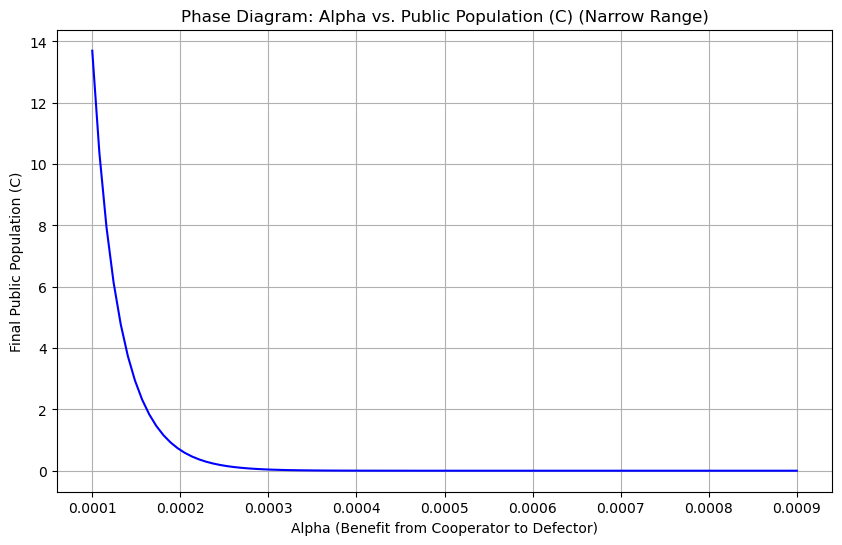

In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters (other than alpha)
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
mu = 0.1  # growth rate (benefit) of cooperator
eta = 0.1  # growth rate (benefit) of private
nu = 0.0001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 100.0, 1.0, 10.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 300, 1000)

# Define a function to compute the phase diagram for alpha values from 0.0001 to 0.001
def plot_phase_diagram_alpha_vs_C_narrow():
    alpha_values = np.linspace(0.0001, 0.0009, 100)  # Vary alpha from 0.0001 to 0.001
    final_C_values = []

    # Loop over alpha values
    for alpha in alpha_values:
        # Integrate the equations over the time grid with varying alpha
        ret_alpha = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
        
        # Store the final public population (C) value for each alpha
        final_C_values.append(ret_alpha[-1][0])  # C is the first component in the state

    # Plotting the phase diagram: alpha vs. final C
    plt.figure(figsize=(10, 6))
    plt.plot(alpha_values, final_C_values, 'b-')
    plt.xlabel('Alpha (Benefit from Cooperator to Defector)')
    plt.ylabel('Final Public Population (C)')
    plt.title('Phase Diagram: Alpha vs. Public Population (C) (Narrow Range)')
    plt.grid(True)
    plt.show()

# Execute the function to generate the plot
plot_phase_diagram_alpha_vs_C_narrow()


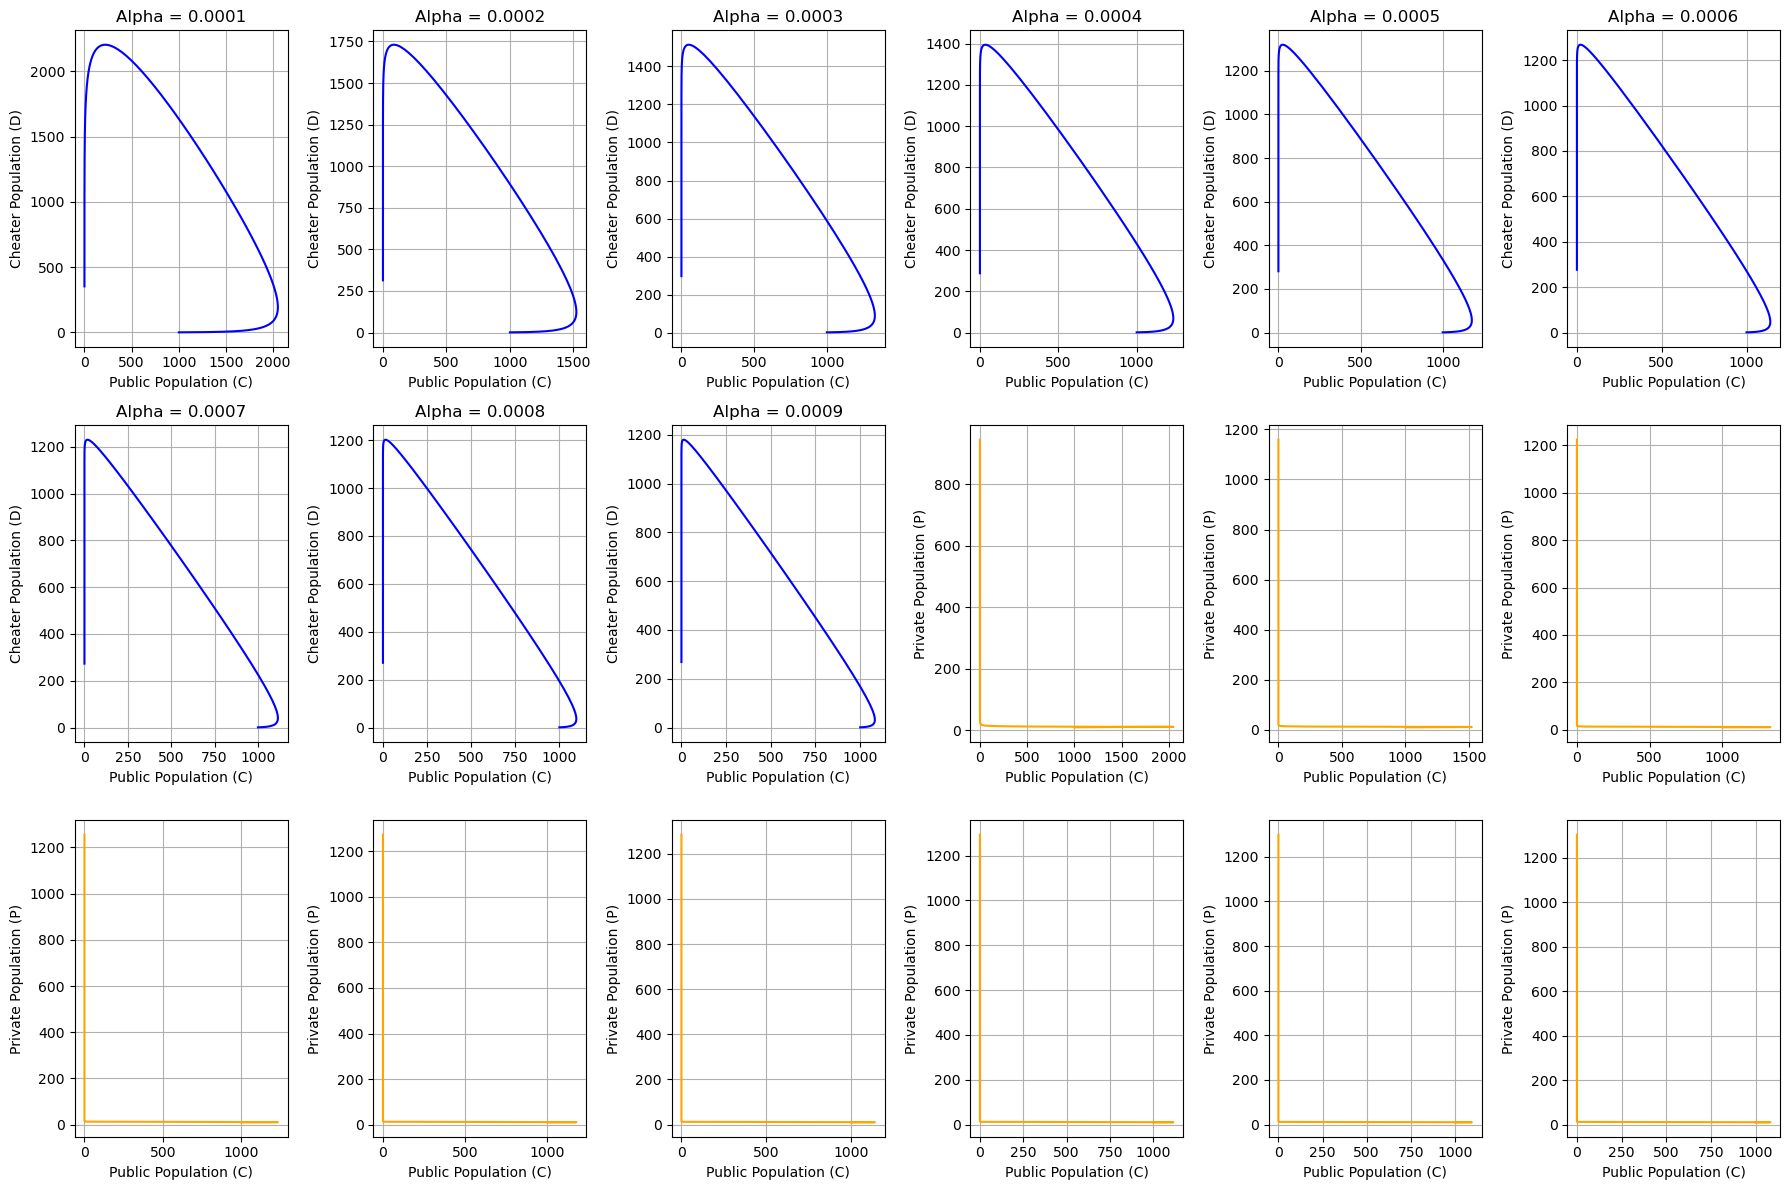

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 1000.0, 1.0, 10.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 300, 1000)

# Alpha values
alpha_values = np.linspace(0.0001, 0.0009, 9)

# Create a figure
plt.figure(figsize=(18, 12))

for i, alpha in enumerate(alpha_values):
    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot phase plots: C vs. D and C vs. P
    plt.subplot(3, 6, i + 1)
    plt.plot(C, D, 'b')
    plt.xlabel('Public Population (C)')
    plt.ylabel('Cheater Population (D)')
    plt.title(f'Alpha = {alpha:.4f}')
    plt.grid(True)

    plt.subplot(3, 6, i + 10)
    plt.plot(C, P, 'orange')
    plt.xlabel('Public Population (C)')
    plt.ylabel('Private Population (P)')
    plt.grid(True)

plt.tight_layout()
plt.show()


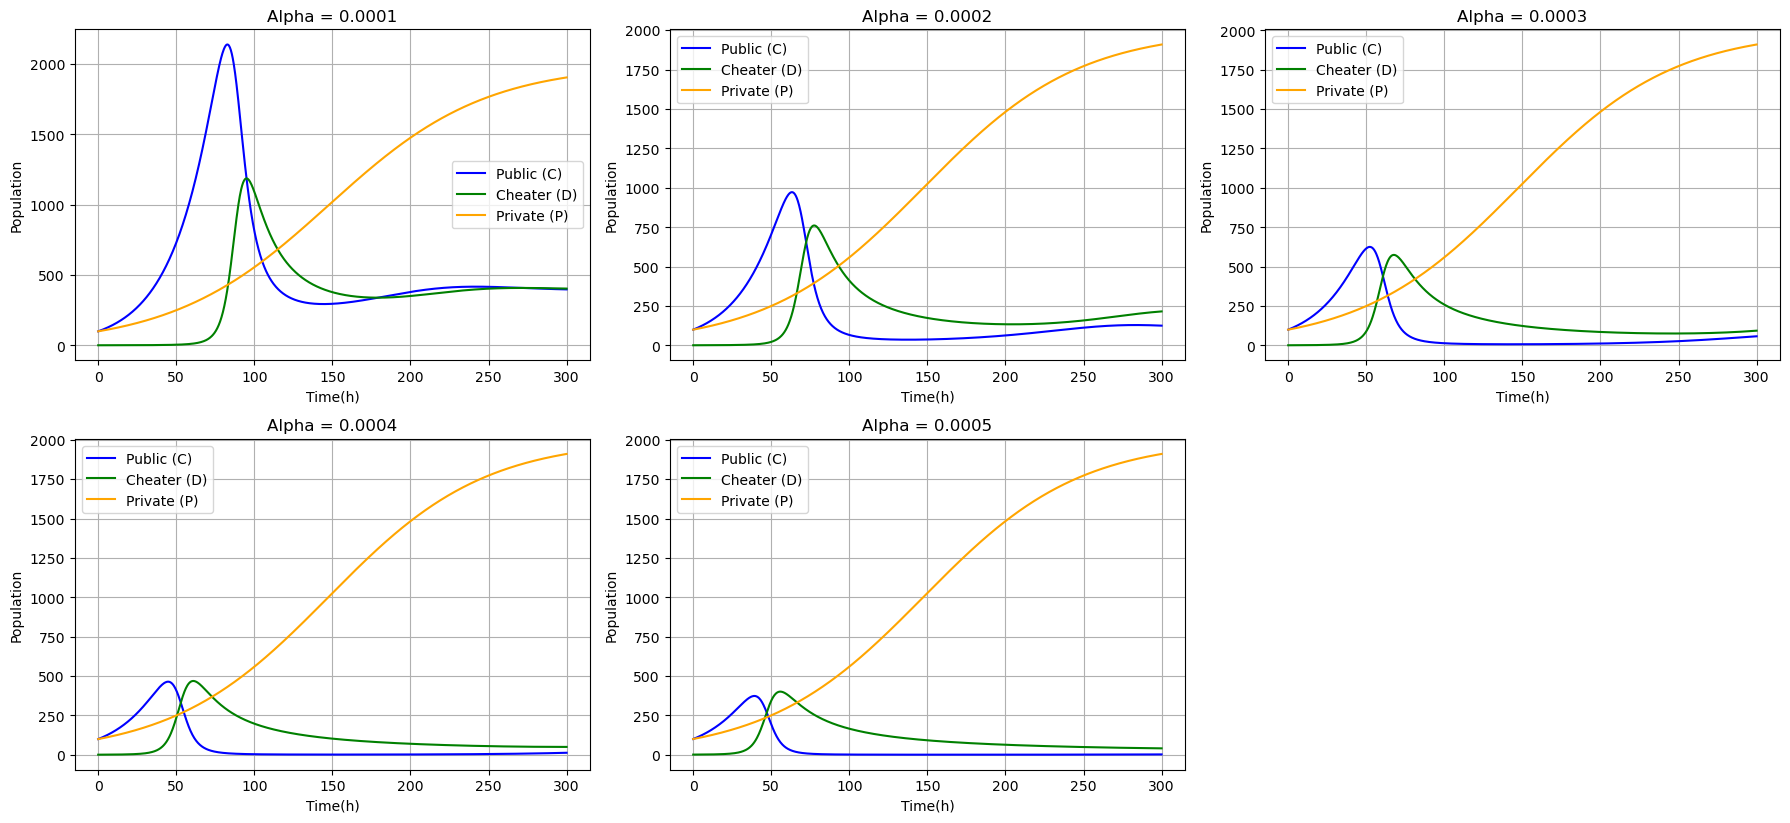

In [22]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.0000001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.0001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 100, 1.0, 100.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 300, 1000)

# Alpha values
alpha_values = np.linspace(0.0001, 0.0005, 5)

# Create a figure
plt.figure(figsize=(18, 12))

for i, alpha in enumerate(alpha_values):
    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot all populations together: Public (C), Cheater (D), and Private (P)
    plt.subplot(3, 3, i + 1)
    plt.plot(t, C, 'blue', label='Public (C)')
    plt.plot(t, D, 'g', label='Cheater (D)')
    plt.plot(t, P, 'orange', label='Private (P)')
    plt.xlabel('Time(h)')
    plt.ylabel('Population')
    plt.title(f'Alpha = {alpha:.4f}')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


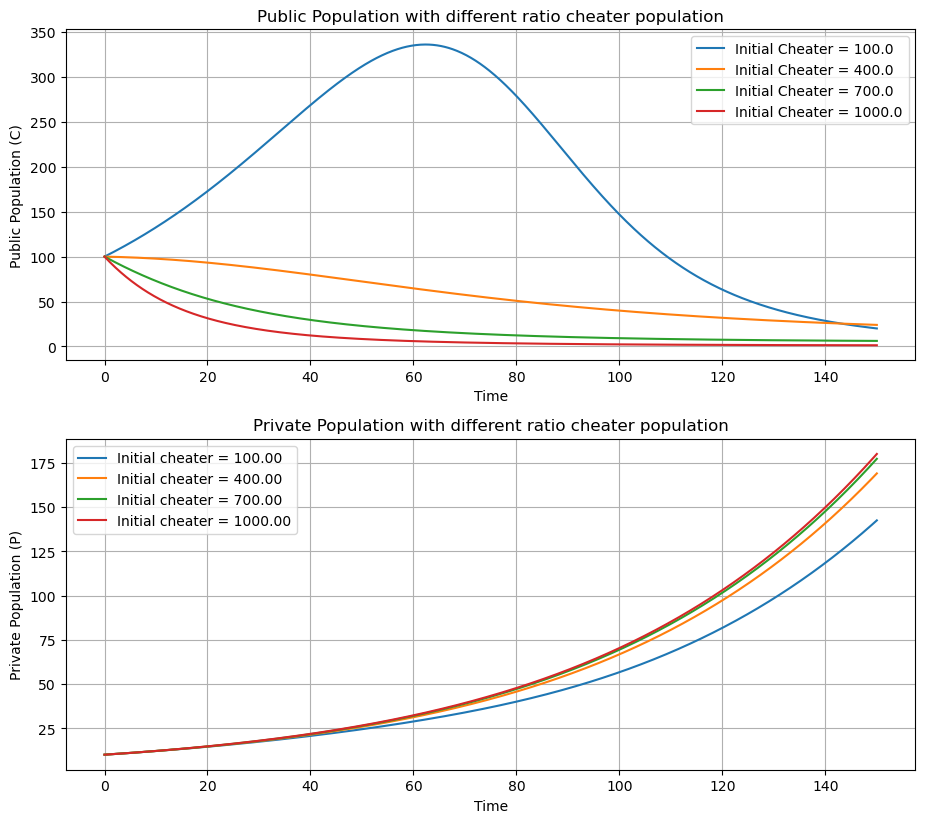

In [55]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of initial populations for defector
D_values = np.linspace(100, 1000, 4)  # D values from 0.1 to 10 (log scale for better spacing)

# Initial conditions
C0, P0 = 100.0, 10.0

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, D0 in enumerate(D_values):
    y0 = C0, D0, P0  # Set initial conditions with varying D0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for C, D, and P
    plt.subplot(3, 2, 1)
    plt.plot(t, C, label=f'Initial Cheater = {D0:.1f}')
    plt.xlabel('Time')
    plt.ylabel('Public Population (C)')
    plt.title('Public Population with different ratio cheater population')
    plt.grid(True)

    plt.subplot(3, 2, 3)
    plt.plot(t, P, label=f'Initial cheater = {D0:.1f}')
    plt.xlabel('Time')
    plt.ylabel('Private Population (P)')
    plt.title('Private Population with different ratio cheater population')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()
plt.subplot(3, 2, 3)
plt.legend()

plt.tight_layout()
plt.show()


Microbiologists also study the human microbiome, the collection of microorganisms living in and on the human body, which plays a vital role in maintaining health. The balance of the microbiome is linked to digestion, immune function, and even mental health, making it a growing area of research.

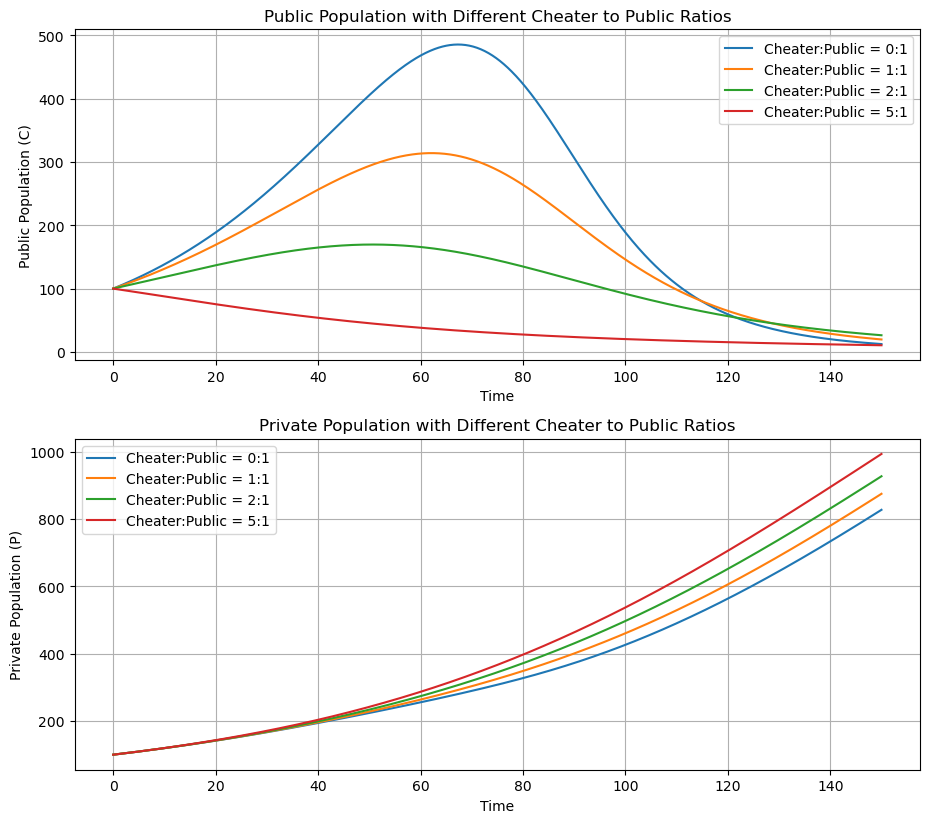

In [67]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of cheater to public population ratios
ratios = [1, 2, 5]  # D/C ratios (cheater to public ratio)

# Initial conditions
C0 = 100.0  # Initial public population (C)
P0 = 100.0   # Initial private population (P)

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, ratio in enumerate(ratios):
    D0 = C0 * ratio  # Set the initial cheater population based on ratio (D0 = C0 * ratio)
    y0 = C0, D0, P0  # Initial conditions: C0, D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for public population (C)
    plt.subplot(3, 2, 1)
    plt.plot(t, C, label=f'Cheater:Public = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Public Population (C)')
    plt.title('Public Population with Different Cheater to Public Ratios')
    plt.grid(True)

    # Plot time-series for private population (P)
    plt.subplot(3, 2, 3)
    plt.plot(t, P, label=f'Cheater:Private = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Private Population (P)')
    plt.title('Private Population with Different Cheater to Public Ratios')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()
plt.subplot(3, 2, 3)
plt.legend()

plt.tight_layout()
plt.show()


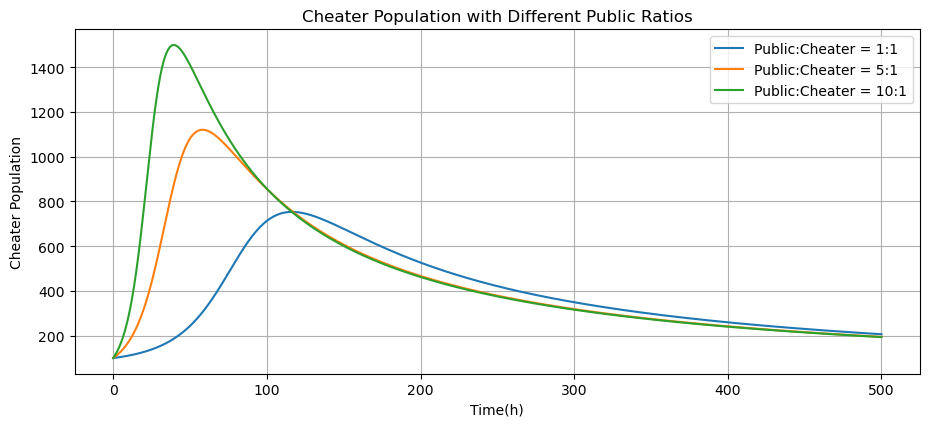

In [72]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of public to cheater population ratios
ratios = [1, 5, 10]  # C/D ratios (public to cheater ratio)

# Initial conditions
D0 = 100.0  # Constant initial cheater population (D)
P0 = 100.0   # Initial private population (P)

# Time grid
t = np.linspace(0, 500, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, ratio in enumerate(ratios):
    C0 = D0 * ratio  # Set the initial public population based on the ratio (C0 = D0 * ratio)
    y0 = C0, D0, P0  # Initial conditions: C0, D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for public population (C)
    plt.subplot(3, 2, 1)
    plt.plot(t, D, label=f'Public:Cheater = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Cheater Population')
    plt.title('Cheater Population with Different Public Ratios')
    plt.grid(True)


# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()

plt.tight_layout()
plt.show()


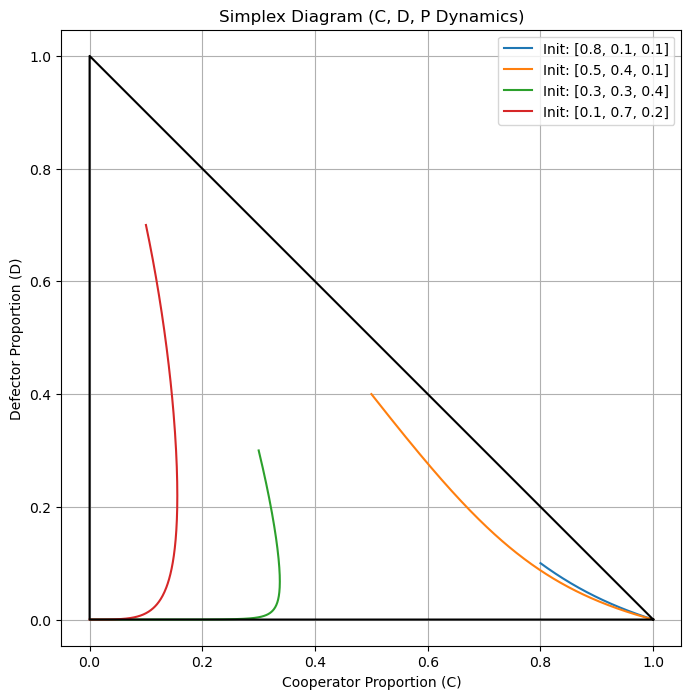

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r_c = 1.0
r_p = 1.0
alpha = 0.5
beta = 0.5
lambda_ = 0.2
nu = 0.3
gamma = 0.3

# Replicator dynamics
def replicator_dynamics(x, t):
    C, D, P = x
    payoff_C = r_c - lambda_ * C - alpha * D - beta * P
    payoff_D = alpha * C - nu * D
    payoff_P = r_p - beta * C - gamma * P
    avg_payoff = C * payoff_C + D * payoff_D + P * payoff_P
    dCdt = C * (payoff_C - avg_payoff)
    dDdt = D * (payoff_D - avg_payoff)
    dPdt = P * (payoff_P - avg_payoff)
    return [dCdt, dDdt, dPdt]

# Initial conditions and time
initial_conditions = [
    [0.8, 0.1, 0.1], [0.5, 0.4, 0.1], [0.3, 0.3, 0.4], [0.1, 0.7, 0.2]
]
t = np.linspace(0, 50, 1000)

# Plotting the Simplex Diagram
plt.figure(figsize=(8, 8))
for ic in initial_conditions:
    trajectory = odeint(replicator_dynamics, ic, t)
    C, D, P = trajectory.T
    plt.plot(C, D, label=f"Init: {ic}")

# Triangle boundary
triangle = np.array([[1, 0], [0, 1], [0, 0], [1, 0]])
plt.plot(triangle[:, 0], triangle[:, 1], 'k-')

# Labels and formatting
plt.title("Simplex Diagram (C, D, P Dynamics)")
plt.xlabel("Cooperator Proportion (C)")
plt.ylabel("Defector Proportion (D)")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()


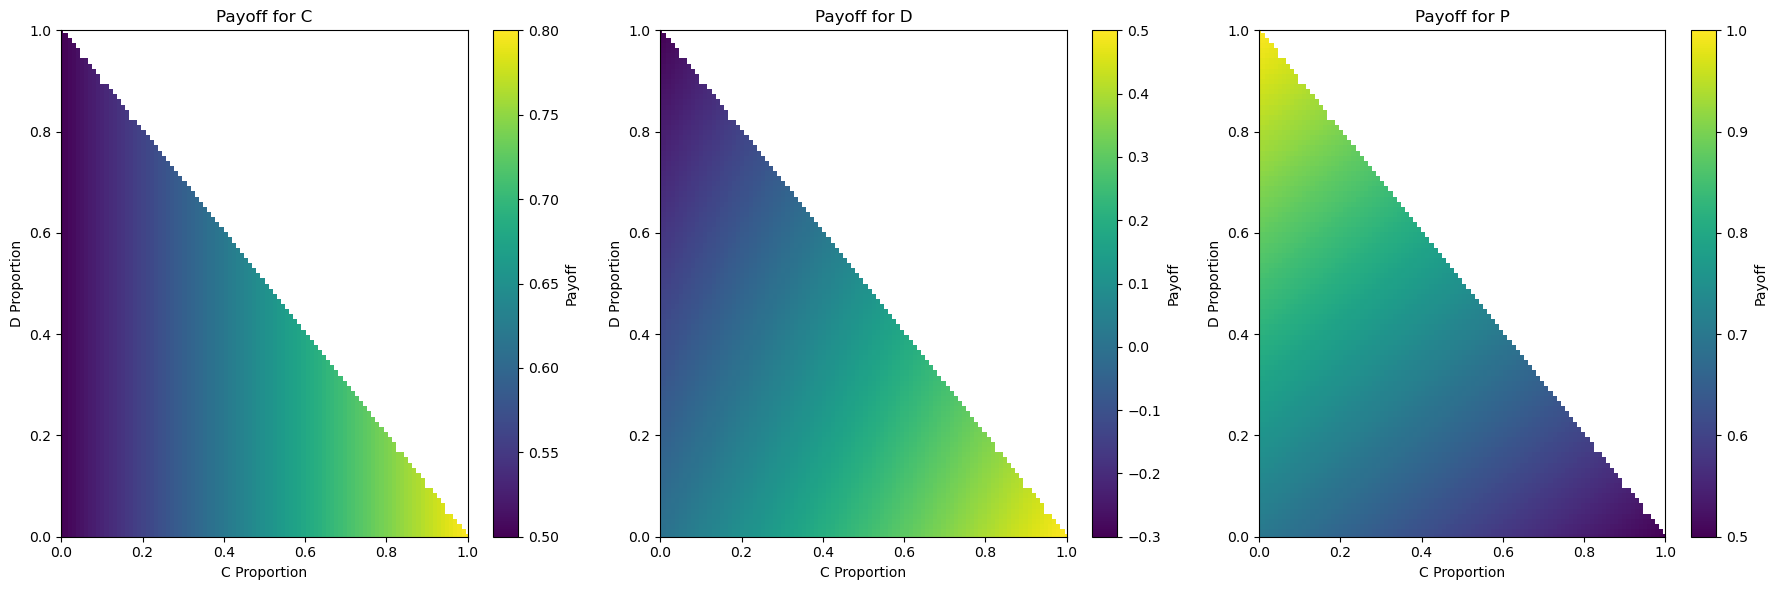

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r_c = 1.0
r_p = 1.0
alpha = 0.5
beta = 0.5
lambda_ = 0.2
nu = 0.3
gamma = 0.3

# Define the payoffs
def payoff_C(C, D, P):
    return r_c - lambda_ * C - alpha * D - beta * P

def payoff_D(C, D, P):
    return alpha * C - nu * D

def payoff_P(C, D, P):
    return r_p - beta * C - gamma * P

# Proportions grid
resolution = 100
C_vals = np.linspace(0, 1, resolution)
D_vals = np.linspace(0, 1, resolution)
C_grid, D_grid = np.meshgrid(C_vals, D_vals)
P_grid = 1 - C_grid - D_grid

# Mask invalid regions where C + D > 1
mask = C_grid + D_grid > 1

# Compute payoffs
payoff_C_grid = payoff_C(C_grid, D_grid, P_grid)
payoff_D_grid = payoff_D(C_grid, D_grid, P_grid)
payoff_P_grid = payoff_P(C_grid, D_grid, P_grid)

# Apply mask
payoff_C_grid[mask] = np.nan
payoff_D_grid[mask] = np.nan
payoff_P_grid[mask] = np.nan

# Plot the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ["Payoff for C", "Payoff for D", "Payoff for P"]
payoff_grids = [payoff_C_grid, payoff_D_grid, payoff_P_grid]

for ax, payoff, title in zip(axes, payoff_grids, titles):
    c = ax.pcolormesh(C_grid, D_grid, payoff, shading='auto', cmap='viridis')
    fig.colorbar(c, ax=ax, label="Payoff")
    ax.set_title(title)
    ax.set_xlabel("C Proportion")
    ax.set_ylabel("D Proportion")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


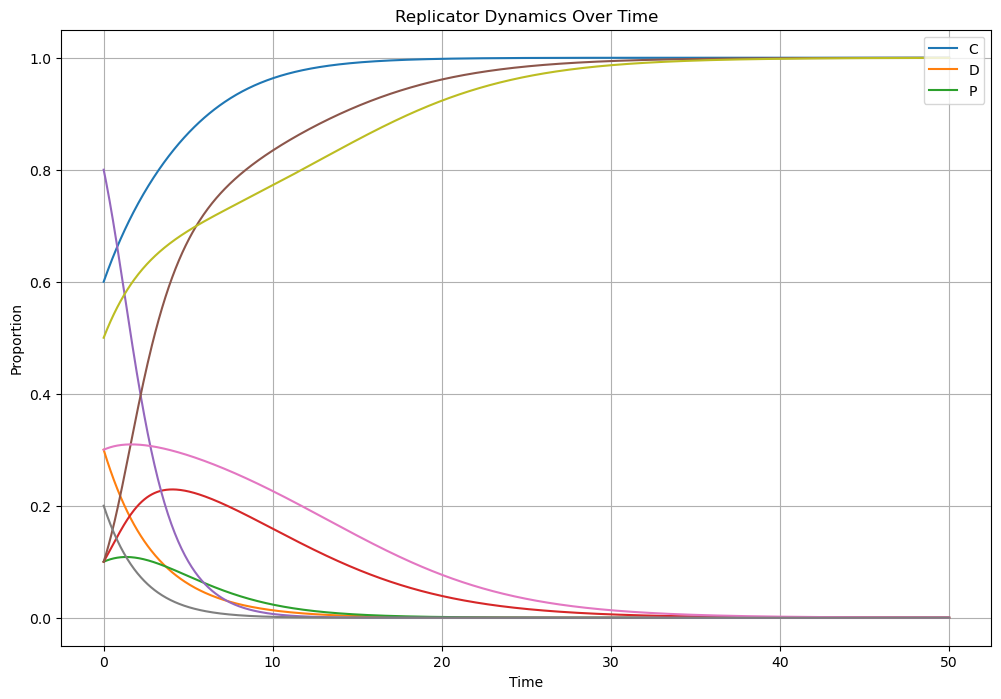

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
r_c = 1.0
r_p = 1.0
alpha = 0.5
beta = 0.5
lambda_ = 0.2
nu = 0.3
gamma = 0.3

# Replicator equations
def replicator_equations(x, t):
    C, D, P = x
    payoff_C = r_c - lambda_ * C - alpha * D - beta * P
    payoff_D = alpha * C - nu * D
    payoff_P = r_p - beta * C - gamma * P
    avg_payoff = C * payoff_C + D * payoff_D + P * payoff_P
    dCdt = C * (payoff_C - avg_payoff)
    dDdt = D * (payoff_D - avg_payoff)
    dPdt = P * (payoff_P - avg_payoff)
    return [dCdt, dDdt, dPdt]

# Initial conditions: different starting points
initial_conditions = [
    [0.6, 0.3, 0.1],  # Mostly cooperators
    [0.1, 0.8, 0.1],  # Mostly defectors
    [0.3, 0.2, 0.5],  # Mixed population
]

# Time span
t = np.linspace(0, 50, 1000)

# Plotting the dynamics
plt.figure(figsize=(12, 8))
for ic in initial_conditions:
    solution = odeint(replicator_equations, ic, t)
    C, D, P = solution.T
    plt.plot(t, C, label=f"C (init: {ic[0]:.1f})")
    plt.plot(t, D, label=f"D (init: {ic[1]:.1f})")
    plt.plot(t, P, label=f"P (init: {ic[2]:.1f})")
    plt.xlabel("Time")
    plt.ylabel("Proportion")
    plt.title("Replicator Dynamics Over Time")
    plt.legend(["C", "D", "P"], loc="upper right")

plt.grid()
plt.show()
